<a href="https://colab.research.google.com/github/dr-koehler-ai/Sepsis-Clinical-Analytics-Project/blob/main/Sepsis_Prediction_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Early Sepsis Prediction from Hourly ICU Data

## Objective

Can routinely collected clinical variables be used to predict the provided hourly SepsisLabel in ICU patients?

## Dataset

- 40,336 ICU patients
- 1,552,210 hourly observations
- Time-varying vital signs and laboratory measurements
- Binary hourly target: `SepsisLabel`

## Workflow

1. Data integrity and label validation
2. Patient-level development/test split
3. Time-aware missing-value handling
4. Feature engineering
5. Grouped cross-validation
6. Logistic regression comparison
7. Random Forest
8. Threshold selection on development data
9. Final evaluation on the untouched test cohort

## Clinical question

Can current clinical measurements, measurement availability and recent clinical trajectories be used to identify patient-hours associated with an upcoming sepsis event?

In [1]:
# Clinical Sepsis Analytics Dashboard (V2)
# =========================================

#Standard library

#Data manipulation
import kagglehub
from pathlib import Path
import pandas as pd
import numpy as np

#Data Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Data modeling
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.metrics import recall_score, accuracy_score, f1_score, precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve
)

# Machine Learning
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone


# =========================
# 1. Dataset Download
# =========================

# Download latest version

dataset_path = kagglehub.dataset_download(
    "salikhussaini49/prediction-of-sepsis"
)

dataset_file = Path(dataset_path) / "Dataset.csv"

dataset_raw_df = pd.read_csv(dataset_file)


# =========================
# 2. Load dataset
# =========================

print("\nShape:", dataset_raw_df.shape)
print("\nColumns:", dataset_raw_df.columns.tolist())
print("\nPatients:", dataset_raw_df["Patient_ID"].nunique())

100%|██████████| 74.7M/74.7M [00:00<00:00, 86.0MB/s]

Extracting files...



Shape: (1552210, 44)

Columns: ['Unnamed: 0', 'Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID']

Patients: 40336


In [2]:
data = dataset_raw_df.drop(
    columns=["Unnamed: 0"],
    errors="ignore"
)

# Sort observations chronologically within each patient
data = (
    data
    .sort_values(["Patient_ID", "ICULOS"])
    .reset_index(drop=True)
)

# Looking for duplicates, missing values, ICU hours
print("Duplicate patient-hours:")
print(data.duplicated(["Patient_ID", "ICULOS"]).sum())

print("\nMissing identifiers:")
print(data[["Patient_ID", "ICULOS", "SepsisLabel"]].isna().sum())

print("\nLabel values:")
print(data["SepsisLabel"].value_counts(dropna=False))

print("\nFirst ICU hour:")
print(data["ICULOS"].min())

print("\nLast ICU hour:")
print(data["ICULOS"].max())

# Select the first available observation for each patient
data_first = (
    data
    .groupby("Patient_ID", as_index=False)
    .head(1)
    .copy()
)

print("Number of first patient rows:", len(data_first))

print("\nLabel distribution:")
print(data_first["SepsisLabel"].value_counts())

print("\nFirst available ICU hour:")
print("Minimum:", data_first["ICULOS"].min())
print("Maximum:", data_first["ICULOS"].max())

# Change compared with the preceding available patient-hour
data["SepsisLabel_change"] = (
    data
    .groupby("Patient_ID")["SepsisLabel"]
    .diff()
)

print("All observed label changes:")
print(data["SepsisLabel_change"].value_counts(dropna=False))

print("\nNumber of 0 → 1 transitions:")
print((data["SepsisLabel_change"] == 1).sum())

print("\nNumber of 1 → 0 transitions:")
print((data["SepsisLabel_change"] == -1).sum())

patients_with_positive_transition = data.loc[
    data["SepsisLabel_change"] == 1,
    "Patient_ID"
].nunique()

patients_with_negative_transition = data.loc[
    data["SepsisLabel_change"] == -1,
    "Patient_ID"
].nunique()

print(
    "Patients with a 0 → 1 transition:",
    patients_with_positive_transition
)

print(
    "Patients with a 1 → 0 transition:",
    patients_with_negative_transition
)

Duplicate patient-hours:
0

Missing identifiers:
Patient_ID     0
ICULOS         0
SepsisLabel    0
dtype: int64

Label values:
SepsisLabel
0    1524294
1      27916
Name: count, dtype: int64

First ICU hour:
1

Last ICU hour:
336
Number of first patient rows: 40336

Label distribution:
SepsisLabel
0    39910
1      426
Name: count, dtype: int64

First available ICU hour:
Minimum: 1
Maximum: 304
All observed label changes:
SepsisLabel_change
0.0    1509368
NaN      40336
1.0       2506
Name: count, dtype: int64

Number of 0 → 1 transitions:
2506

Number of 1 → 0 transitions:
0
Patients with a 0 → 1 transition: 2506
Patients with a 1 → 0 transition: 0


## Data Integrity and Temporal Label Validation

The redundant index column was removed, and observations were ordered chronologically by patient and ICU length of stay. No duplicate patient-hours or missing values in `Patient_ID`, `ICULOS`, or `SepsisLabel` were identified.

The dataset contained 40,336 patients, of whom 2,932 (7.27%) had at least one positive SepsisLabel. A patient-level outcome summary was created for descriptive purposes only; clinical predictor variables remained at the hourly level.

For 426 patients, the first available observation was already positive. Among the remaining sepsis patients, 2,506 showed an observed transition from `SepsisLabel = 0` to `SepsisLabel = 1`. No transitions from 1 back to 0 were found, confirming that the target followed the expected temporal pattern within each patient record.

In [3]:
patient_outcomes = (
    data
    .groupby("Patient_ID", as_index=False)["SepsisLabel"]
    .max()
    .rename(columns={"SepsisLabel": "SepsisPatient"})
)

print(patient_outcomes.shape)
print(patient_outcomes["SepsisPatient"].value_counts())

development_patients, test_patients = train_test_split(
    patient_outcomes,
    test_size=0.20,
    random_state=42,
    stratify=patient_outcomes["SepsisPatient"]
)

print("Development patients:", len(development_patients))
print("Test patients:", len(test_patients))

development_ids = development_patients["Patient_ID"]
test_ids = test_patients["Patient_ID"]

development_data = data[
    data["Patient_ID"].isin(development_ids)
].copy()

test_data = data[
    data["Patient_ID"].isin(test_ids)
].copy()

print("Development:")
print("  Rows:", len(development_data))
print("  Patients:", development_data["Patient_ID"].nunique())

print("\nFinal test:")
print("  Rows:", len(test_data))
print("  Patients:", test_data["Patient_ID"].nunique())

patient_overlap = set(
    development_data["Patient_ID"]
).intersection(
    set(test_data["Patient_ID"])
)

print("Overlapping patients:", len(patient_overlap))

development_patient_prevalence = (
    development_data
    .groupby("Patient_ID")["SepsisLabel"]
    .max()
    .mean()
)

test_patient_prevalence = (
    test_data
    .groupby("Patient_ID")["SepsisLabel"]
    .max()
    .mean()
)

print(
    "Development patient prevalence:",
    f"{development_patient_prevalence:.2%}"
)

print(
    "Test patient prevalence:",
    f"{test_patient_prevalence:.2%}"
)

print(
    "Development hourly positive rate:",
    f"{development_data['SepsisLabel'].mean():.2%}"
)

print(
    "Test hourly positive rate:",
    f"{test_data['SepsisLabel'].mean():.2%}"
)

(40336, 2)
SepsisPatient
0    37404
1     2932
Name: count, dtype: int64
Development patients: 32268
Test patients: 8068
Development:
  Rows: 1240596
  Patients: 32268

Final test:
  Rows: 311614
  Patients: 8068
Overlapping patients: 0
Development patient prevalence: 7.27%
Test patient prevalence: 7.26%
Development hourly positive rate: 1.80%
Test hourly positive rate: 1.78%


## Patient-Level Development/Test Split

A patient-level outcome was created using the maximum SepsisLabel recorded during each ICU stay. This patient-level variable was used only to stratify the split.

Patients were divided into an 80% development cohort and a 20% final test cohort. All hourly observations belonging to one patient remained in the same cohort, preventing patient-level data leakage.

The prevalence of patients with at least one positive SepsisLabel was approximately 7.3% in both cohorts. The final test cohort was not used for model selection, cross-validation or threshold selection.

## Hourly Missingness and Time-Aware Preprocessing

Missingness was assessed at the patient-hour level using the development dataset only. Vital signs were recorded relatively frequently, whereas laboratory variables were often unavailable because they were not measured every hour. Therefore, high hourly missingness does not necessarily mean that a variable was never measured during a patient’s ICU stay.

To retain clinically relevant information without using future observations, the last available measurement was carried forward within each patient for a maximum of six hours. Records were ordered by `Patient_ID` and `ICULOS`, and the hourly sequence was verified to contain no duplicate or missing time intervals. Forward filling was performed separately within each patient, preventing information transfer between patients.

For every time-varying clinical variable, an additional binary indicator was created before forward filling to show whether a new measurement was recorded during the current hour. These indicators allow later model comparisons to assess whether clinical measurement behavior contributes predictive information.

Values unavailable before a patient’s first measurement, or more than six hours after the last measurement, remained missing. These remaining values will be imputed within the model pipeline so that imputation parameters are learned exclusively from the corresponding training folds.

Two feature sets were prepared for comparison:

1. Clinical values after time-limited forward filling.
2. The same clinical values combined with hourly measurement indicators.

The target was the provided hourly `SepsisLabel`, which had already been shifted six hours before the defined clinical sepsis onset by the dataset creators. `Patient_ID` was retained only as the grouping variable for patient-level cross-validation and was not included as a model feature.

In [4]:
# 1. HOURLY MISSINGNESS IN THE DEVELOPMENT DATA

# Calculating the percentage of missing values across all
# patient-hours in the development dataset.
# This describes missing patient-hours, not the percentage
# of patients who never had a variable measured.

hourly_missingness = (
    development_data
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(1)
)

# Converting the resulting Series into a one-column DataFrame
# to make the output easier to read.
hourly_missingness = hourly_missingness.to_frame(
    name="Missing patient-hours (%)"
)

display(hourly_missingness)


# 2. DEFINE TIME-VARYING CLINICAL VARIABLES

# These variables can change over time and may therefore
# be carried forward within a patient's chronological record.

measurement_features = [
    "HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp",
    "EtCO2", "BaseExcess", "HCO3", "FiO2", "pH", "PaCO2",
    "SaO2", "AST", "BUN", "Alkalinephos", "Calcium",
    "Chloride", "Creatinine", "Bilirubin_direct", "Glucose",
    "Lactate", "Magnesium", "Phosphate", "Potassium",
    "Bilirubin_total", "TroponinI", "Hct", "Hgb", "PTT",
    "WBC", "Fibrinogen", "Platelets"
]


# 3. PREPARING THE DEVELOPMENT DATA

# Sort all observations chronologically within each patient.
development_prepared = (
    development_data
    .sort_values(["Patient_ID", "ICULOS"])
    .reset_index(drop=True)
    .copy()
)

# 4. VERIFY THE HOURLY TIME SEQUENCE

# Calculating the difference between the current ICU hour and
# the preceding available ICU hour for the same patient.
development_prepared["ICULOS_difference"] = (
    development_prepared
    .groupby("Patient_ID")["ICULOS"]
    .diff()
)

print("Observed ICULOS differences:")
print(
    development_prepared["ICULOS_difference"]
    .value_counts(dropna=False)
    .sort_index()
)

# Storing the audit column under a shorter name for the checks.
iculos_difference = development_prepared["ICULOS_difference"]

print(
    "Differences equal to 1:",
    (iculos_difference == 1).sum()
)

print(
    "Differences greater than 1:",
    (iculos_difference > 1).sum()
)

print(
    "Differences equal to or below 0:",
    (iculos_difference <= 0).sum()
)

# Count patients with at least one gap of more than one hour.
patients_with_time_gaps = development_prepared.loc[
    development_prepared["ICULOS_difference"] > 1,
    "Patient_ID"
].nunique()

print(
    "Patients with at least one time gap:",
    patients_with_time_gaps
)

# Display the ten largest time gaps, if any exist.
print(
    development_prepared.loc[
        development_prepared["ICULOS_difference"] > 1,
        ["Patient_ID", "ICULOS", "ICULOS_difference"]
    ]
    .sort_values("ICULOS_difference", ascending=False)
    .head(10)
)

# ICULOS_difference was created only for data validation.
development_prepared = development_prepared.drop(
    columns="ICULOS_difference"
)


# 5. CREATE HOURLY MEASUREMENT INDICATORS

# Creating one binary indicator for each time-varying feature (1 column for each variable!).
# A value of 1 means that a new measurement was recorded
# during the current patient-hour.

for feature in measurement_features:
    development_prepared[f"{feature}_measured_now"] = (
        development_prepared[feature]
        .notna()
        .astype("int8")
    )


# 6. TIME-LIMITED FORWARD FILL

# Carry the last observed value forward within the same patient
# for a maximum of six subsequent hours.
# Forward filling is performed separately for each Patient_ID,
# preventing values from being transferred between patients.

development_prepared[measurement_features] = (
    development_prepared
    .groupby("Patient_ID")[measurement_features]
    .ffill(limit=6)
)


# 7. COMPARE MISSINGNESS BEFORE AND AFTER FORWARD FILL

missingness_comparison = pd.DataFrame({
    # Original hourly missingness
    "Before_forward_fill": (
        development_data[measurement_features]
        .isna()
        .mean()
        .mul(100)
    ),

    # Missingness after time-limited forward filling
    "After_forward_fill": (
        development_prepared[measurement_features]
        .isna()
        .mean()
        .mul(100)
    )
})

# Calculate the absolute reduction in percentage points.
missingness_comparison["Reduction"] = (
    missingness_comparison["Before_forward_fill"]
    - missingness_comparison["After_forward_fill"]
)

# Sort variables by their remaining missingness.
missingness_comparison = (
    missingness_comparison
    .sort_values("After_forward_fill", ascending=False)
    .round(1)
)

display(missingness_comparison)


# 8. DEFINE THE MODEL FEATURE SETS

# Clinical values include all time-varying measurements plus
# demographic and current ICU-time information.
value_features = measurement_features + [
    "Age",
    "Gender",
    "ICULOS"
]

# Create a list containing the names of the previously generated
# measurement-indicator columns.
measurement_indicator_features = [
    f"{feature}_measured_now"
    for feature in measurement_features
]

# Feature set A:
# Clinical values without measurement indicators.
X_values = development_prepared[
    value_features
].copy()

# Feature set B:
# Clinical values plus hourly measurement indicators.
features_with_indicators = (
    value_features
    + measurement_indicator_features
)

X_values_indicators = development_prepared[
    features_with_indicators
].copy()


# 9. DEFINE TARGET AND PATIENT GROUPS

# One-dimensional hourly prediction target.
y = development_prepared["SepsisLabel"].copy()

# Patient IDs are used only to keep all hours belonging to the
# same patient together during cross-validation.
groups = development_prepared["Patient_ID"].copy()


# 10. SELECT THE FEATURE SET FOR A MODEL

# Start with the simpler value-only model:
X = X_values

# 11. FINAL CONSISTENCY CHECKS

print("X values shape:", X_values.shape)

print(
    "X values + indicators shape:",
    X_values_indicators.shape
)

print("y shape:", y.shape)
print("groups shape:", groups.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget prevalence:")
print(f"{y.mean():.2%}")

print(
    "\nNumber of patients:",
    groups.nunique()
)

# Confirm that identifiers, target-derived variables and audit
# columns were not accidentally included in the model features.
forbidden_features = {
    "Patient_ID",
    "SepsisLabel",
    "SepsisLabel_change",
    "ICULOS_difference"
}

print(
    "\nForbidden features in X_values:",
    forbidden_features.intersection(X_values.columns)
)

print(
    "Forbidden features in X_values_indicators:",
    forbidden_features.intersection(
        X_values_indicators.columns
    )
)

,Missing patient-hours (%)
Bilirubin_direct,99.8
Fibrinogen,99.3
TroponinI,99.0
Bilirubin_total,98.5
Alkalinephos,98.4
AST,98.4
Lactate,97.3
PTT,97.0
SaO2,96.5
EtCO2,96.3


Observed ICULOS differences:
ICULOS_difference
1.0    1208328
NaN      32268
Name: count, dtype: int64
Differences equal to 1: 1208328
Differences greater than 1: 0
Differences equal to or below 0: 0
Patients with at least one time gap: 0
Empty DataFrame
Columns: [Patient_ID, ICULOS, ICULOS_difference]
Index: []


,Before_forward_fill,After_forward_fill,Reduction
Bilirubin_direct,99.8,98.8,1.0
Fibrinogen,99.3,96.4,2.9
EtCO2,96.3,95.1,1.2
TroponinI,99.0,94.1,4.9
Bilirubin_total,98.5,90.3,8.2
Alkalinephos,98.4,90.2,8.1
AST,98.4,90.1,8.2
Lactate,97.3,88.7,8.7
SaO2,96.5,86.4,10.2
PTT,97.0,81.8,15.2


X values shape: (1240596, 37)
X values + indicators shape: (1240596, 71)
y shape: (1240596,)
groups shape: (1240596,)

Target distribution:
SepsisLabel
0    1218233
1      22363
Name: count, dtype: int64

Target prevalence:
1.80%

Number of patients: 32268

Forbidden features in X_values: set()
Forbidden features in X_values_indicators: set()


## Dummy Classifier Baseline

A `DummyClassifier` using the class prior was evaluated with five-fold stratified group cross-validation. All observations from the same patient were kept within a single fold to prevent patient-level data leakage.

The classifier predicted the majority class (`Non-Sepsis`) for every patient-hour. It achieved approximately 98% accuracy but failed to identify any positive SepsisLabel hours, resulting in a sepsis recall and F1-score of 0. Its ROC-AUC was approximately 0.50, while the Average Precision was approximately 0.018, corresponding to the positive hourly label prevalence.

These results demonstrate that accuracy is misleading in this highly imbalanced dataset. The dummy classifier provides a minimum reference against which all subsequent models must be compared.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.98      1.00      0.99   1218233
           1       0.00      0.00      0.00     22363

    accuracy                           0.98   1240596
   macro avg       0.49      0.50      0.50   1240596
weighted avg       0.96      0.98      0.97   1240596



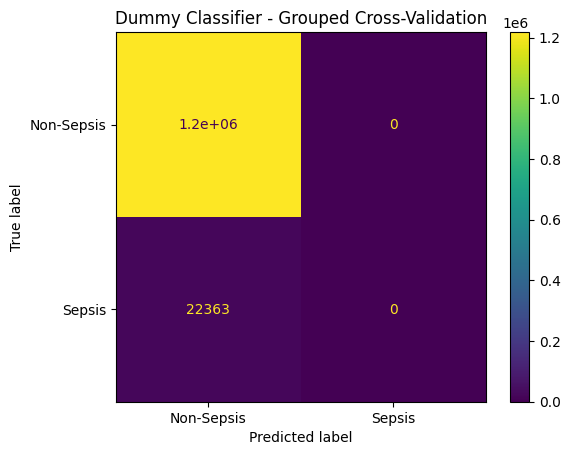

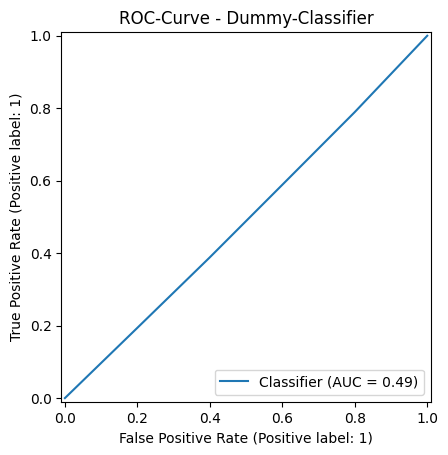

ROC-AUC: 0.492


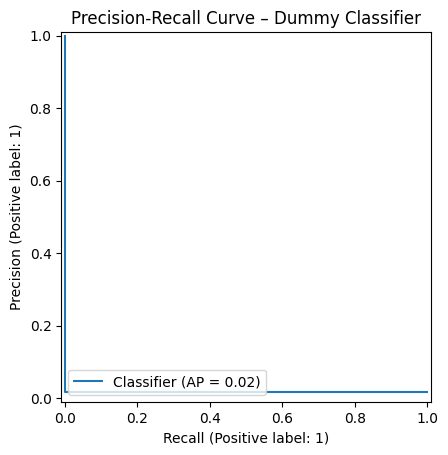

Average Precision: 0.018


In [5]:
# Define the cross-validation splitter
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

dummy_model = DummyClassifier(strategy="prior")
dummy_pred = cross_val_predict(dummy_model, X,y, groups=groups, cv=cv, method="predict")
dummy_prob = cross_val_predict(
    dummy_model,
    X,
    y,
    groups=groups,
    cv=cv,
    method="predict_proba"
)[:, 1]

#Classification Report
print(classification_report(y, dummy_pred))

#Confusion Matrix
cm = confusion_matrix(y, dummy_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Sepsis", "Sepsis"])
disp.plot()
plt.title("Dummy Classifier - Grouped Cross-Validation")
plt.show()

#ROC Curve using probabilities
RocCurveDisplay.from_predictions(y, dummy_prob)
plt.title("ROC-Curve - Dummy-Classifier")
plt.show()

dummy_roc_auc = roc_auc_score(y, dummy_prob)
print(f"ROC-AUC: {dummy_roc_auc:.3f}")

PrecisionRecallDisplay.from_predictions(
    y,
    dummy_prob
)

plt.title("Precision-Recall Curve – Dummy Classifier")
plt.show()

dummy_average_precision = average_precision_score(
    y,
    dummy_prob
)

print(
    "Average Precision:",
    f"{dummy_average_precision:.3f}"
)

**Logistic Regression**

              precision    recall  f1-score   support

           0       0.99      0.76      0.86   1218233
           1       0.04      0.62      0.08     22363

    accuracy                           0.75   1240596
   macro avg       0.52      0.69      0.47   1240596
weighted avg       0.97      0.75      0.84   1240596



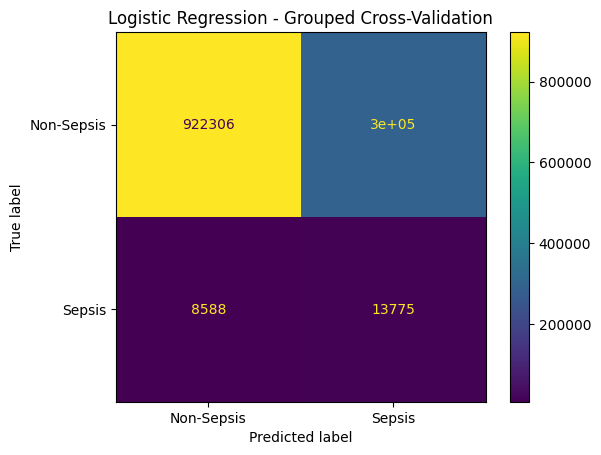

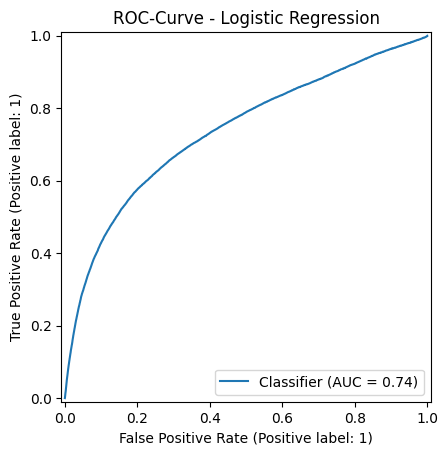

ROC-AUC: 0.736


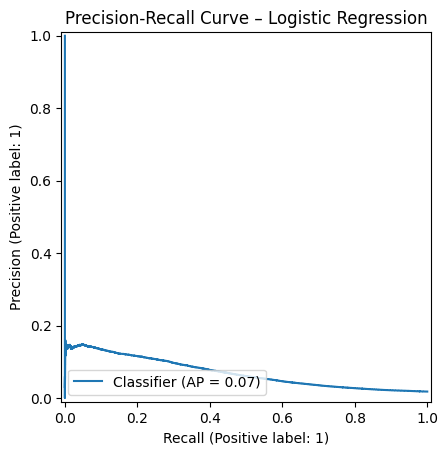

Average Precision: 0.070


In [6]:
# Balanced Logistic Regression Pipeline

balanced_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ))
])

# Predictions

lgr_prob = cross_val_predict(
    balanced_pipeline,
    X,
    y,
    groups=groups,
    cv=cv,
    method="predict_proba"
)[:, 1]

lgr_pred = (lgr_prob >= 0.5).astype(int)

# Classification Report

print(classification_report(y, lgr_pred))

# Confusion Matrix

cm = confusion_matrix(y, lgr_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Sepsis", "Sepsis"])
disp.plot()
plt.title("Logistic Regression - Grouped Cross-Validation")
plt.show()

# ROC Curve and ROC-AUC

RocCurveDisplay.from_predictions(y, lgr_prob) # Use probabilities for ROC curve
plt.title("ROC-Curve - Logistic Regression")
plt.show()

lgr_roc_auc = roc_auc_score(y, lgr_prob)
print(f"ROC-AUC: {lgr_roc_auc:.3f}")

# Precision-Recall Curve and PR-AUC

PrecisionRecallDisplay.from_predictions(
    y,
    lgr_prob
)

plt.title("Precision-Recall Curve – Logistic Regression")
plt.show()

lgr_average_precision = average_precision_score(
    y,
    lgr_prob
)

print(
    "Average Precision:",
    f"{lgr_average_precision:.3f}"
)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99   1218233
           1       0.17      0.00      0.01     22363

    accuracy                           0.98   1240596
   macro avg       0.57      0.50      0.50   1240596
weighted avg       0.97      0.98      0.97   1240596



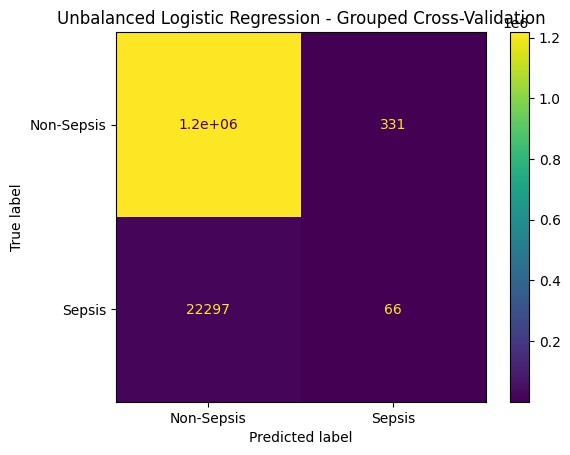

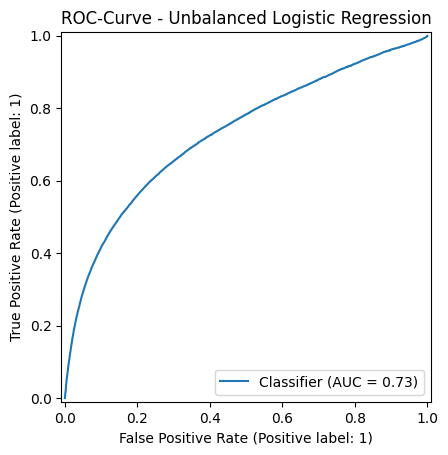

ROC-AUC: 0.730


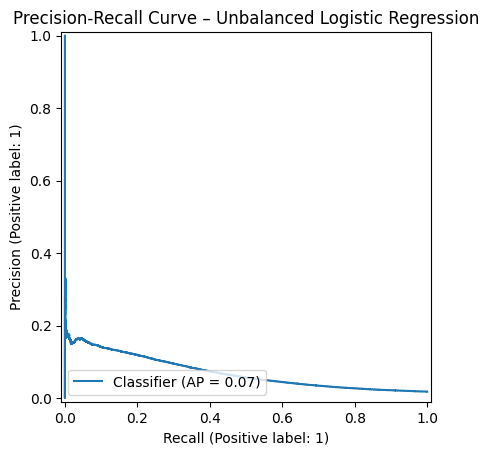

Average Precision: 0.071


In [7]:
# Unbalanced Logistic Regression Pipeline

unbalanced_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

# Predictions

lgr_ub_prob = cross_val_predict(
    unbalanced_pipeline,
    X,
    y,
    groups=groups,
    cv=cv,
    method="predict_proba"
)[:, 1]

lgr_ub_pred = (lgr_ub_prob >= 0.5).astype(int)


# Classification Report

print(classification_report(y, lgr_ub_pred))


# Confusion Matrix

cm = confusion_matrix(y, lgr_ub_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Sepsis", "Sepsis"])
disp.plot()
plt.title("Unbalanced Logistic Regression - Grouped Cross-Validation")
plt.show()


# ROC Curve and ROC-AUC

RocCurveDisplay.from_predictions(y, lgr_ub_prob)
plt.title("ROC-Curve - Unbalanced Logistic Regression")
plt.show()

ub_lgr_roc_auc = roc_auc_score(y, lgr_ub_prob)
print(f"ROC-AUC: {ub_lgr_roc_auc:.3f}")


# Precision-Recall Curve and PR-AUC

PrecisionRecallDisplay.from_predictions(
    y,
    lgr_ub_prob
)

plt.title("Precision-Recall Curve – Unbalanced Logistic Regression")
plt.show()

ub_lgr_average_precision = average_precision_score(
    y,
    lgr_ub_prob
)

print(
    "Average Precision:",
    f"{ub_lgr_average_precision:.3f}"
)

              precision    recall  f1-score   support

  Non-Sepsis       0.98      1.00      0.99   1218233
      Sepsis       0.22      0.00      0.01     22363

    accuracy                           0.98   1240596
   macro avg       0.60      0.50      0.50   1240596
weighted avg       0.97      0.98      0.97   1240596



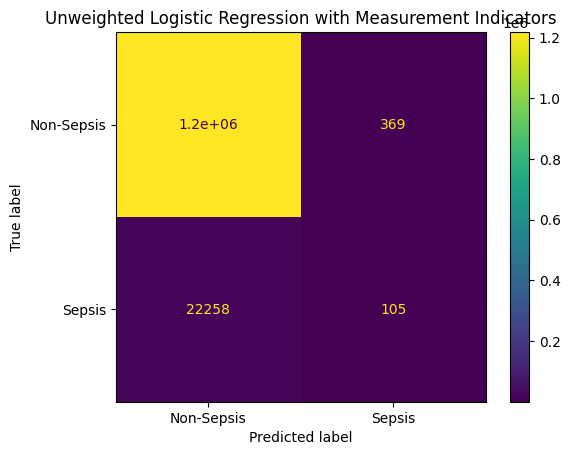

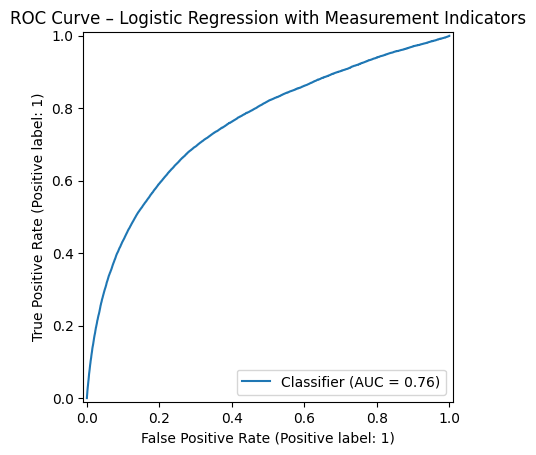

ROC-AUC: 0.755


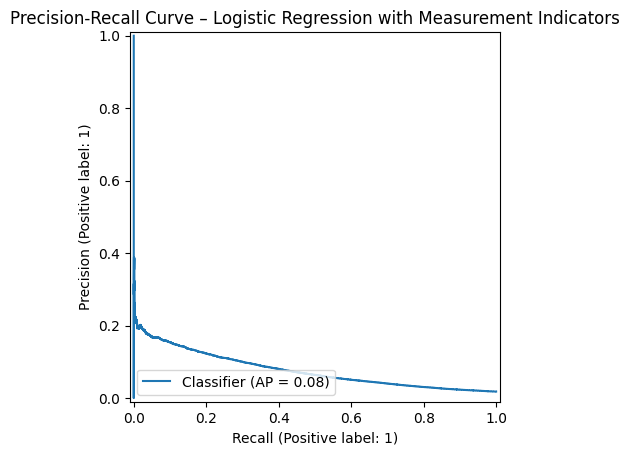

Average Precision: 0.077


In [8]:
# =========================================================
# UNWEIGHTED LOGISTIC REGRESSION WITH MEASUREMENT INDICATORS
# =========================================================

# Use clinical values together with hourly measurement indicators.
X_indicators = X_values_indicators


# Model pipeline

unweighted_indicator_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            random_state=42,
            max_iter=1000
        )
    )
])

# Grouped cross-validation.
lgr_ind_prob = cross_val_predict(
    unweighted_indicator_pipeline,
    X_indicators,
    y,
    groups=groups,
    cv=cv,
    method="predict_proba"
)[:, 1]

# Threshold of 0.5.
lgr_ind_pred = (
    lgr_ind_prob >= 0.5
).astype(int)


# Classification Report

print(
    classification_report(
        y,
        lgr_ind_pred,
        target_names=["Non-Sepsis", "Sepsis"],
        zero_division=0
    )
)


# Confusion Matrix

cm_ind = confusion_matrix(
    y,
    lgr_ind_pred
)

disp_ind = ConfusionMatrixDisplay(
    confusion_matrix=cm_ind,
    display_labels=["Non-Sepsis", "Sepsis"]
)

disp_ind.plot()
plt.title(
    "Unweighted Logistic Regression with Measurement Indicators"
)
plt.show()


# ROC Curve and ROC-AUC

RocCurveDisplay.from_predictions(
    y,
    lgr_ind_prob
)

plt.title(
    "ROC Curve – Logistic Regression with Measurement Indicators"
)
plt.show()

lgr_ind_roc_auc = roc_auc_score(
    y,
    lgr_ind_prob
)

print(
    "ROC-AUC:",
    f"{lgr_ind_roc_auc:.3f}"
)


# Precision-Recall Curve and Average Precision

PrecisionRecallDisplay.from_predictions(
    y,
    lgr_ind_prob
)

plt.title(
    "Precision-Recall Curve – Logistic Regression "
    "with Measurement Indicators"
)
plt.show()

lgr_ind_average_precision = average_precision_score(
    y,
    lgr_ind_prob
)

print(
    "Average Precision:",
    f"{lgr_ind_average_precision:.3f}"
)

In [9]:
# =========================================================
# COMPLETE LOGISTIC REGRESSION COMPARISON
# =========================================================


# MODEL-SUMMARY FUNCTION

def summarize_model(
    model_name,
    y_true,
    y_pred,
    y_prob
):
    """
    Summarize threshold-independent and threshold-dependent
    model performance using out-of-fold predictions.
    """

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    specificity = tn / (tn + fp)

    return {
        "Model": model_name,

        # Threshold-independent discrimination
        "ROC_AUC": roc_auc_score(
            y_true,
            y_prob
        ),
        "Average_Precision": average_precision_score(
            y_true,
            y_prob
        ),

        # Metrics at the default threshold of 0.5
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "Sepsis_Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Sepsis_Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Sepsis_F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Specificity": specificity,

        # Confusion-matrix counts
        "True_Positives": tp,
        "False_Positives": fp,
        "False_Negatives": fn,
        "True_Negatives": tn,

        # Approximate hourly alarm burden
        "Warnings_per_100_hours": (
            y_pred.mean() * 100
        ),
        "False_alarms_per_100_hours": (
            fp / len(y_true) * 100
        )
    }


# COMPLETE MODEL-COMPARISON TABLE

logistic_model_comparison = pd.DataFrame([
    summarize_model(
        model_name="Dummy classifier",
        y_true=y,
        y_pred=dummy_pred,
        y_prob=dummy_prob
    ),
    summarize_model(
        model_name="Balanced LR – values",
        y_true=y,
        y_pred=lgr_pred,
        y_prob=lgr_prob
    ),
    summarize_model(
        model_name="Unweighted LR – values",
        y_true=y,
        y_pred=lgr_ub_pred,
        y_prob=lgr_ub_prob
    ),
    summarize_model(
        model_name="Unweighted LR – values + indicators",
        y_true=y,
        y_pred=lgr_ind_pred,
        y_prob=lgr_ind_prob
    )
])

display(
    logistic_model_comparison.round(3)
)


# COMPACT PORTFOLIO TABLE

comparison_columns = [
    "Model",
    "ROC_AUC",
    "Average_Precision",
    "Sepsis_Precision",
    "Sepsis_Recall",
    "Sepsis_F1",
    "Specificity",
    "Warnings_per_100_hours",
    "False_alarms_per_100_hours"
]

logistic_model_comparison_compact = (
    logistic_model_comparison[
        comparison_columns
    ]
    .round(3)
)

display(
    logistic_model_comparison_compact
)

,Model,ROC_AUC,Average_Precision,Accuracy,Sepsis_Precision,Sepsis_Recall,Sepsis_F1,Specificity,True_Positives,False_Positives,False_Negatives,True_Negatives,Warnings_per_100_hours,False_alarms_per_100_hours
0,Dummy classifier,0.492,0.018,0.982,0.000,0.000,0.000,1.000,0,0,22363,1218233,0.000,0.000
1,Balanced LR – values,0.736,0.070,0.755,0.044,0.616,0.083,0.757,13775,295927,8588,922306,24.964,23.854
2,Unweighted LR – values,0.730,0.071,0.982,0.166,0.003,0.006,1.000,66,331,22297,1217902,0.032,0.027
3,Unweighted LR – values + indicators,0.755,0.077,0.982,0.222,0.005,0.009,1.000,105,369,22258,1217864,0.038,0.030


,Model,ROC_AUC,Average_Precision,Sepsis_Precision,Sepsis_Recall,Sepsis_F1,Specificity,Warnings_per_100_hours,False_alarms_per_100_hours
0,Dummy classifier,0.492,0.018,0.000,0.000,0.000,1.000,0.000,0.000
1,Balanced LR – values,0.736,0.070,0.044,0.616,0.083,0.757,24.964,23.854
2,Unweighted LR – values,0.730,0.071,0.166,0.003,0.006,1.000,0.032,0.027
3,Unweighted LR – values + indicators,0.755,0.077,0.222,0.005,0.009,1.000,0.038,0.030


In [10]:
# =========================================================
# TEMPORAL FEATURES AND FINAL LOGISTIC REGRESSION MODEL
# =========================================================


# PREPARE TEMPORAL DATA, Create a new copy

development_temporal = (
    development_prepared
    .sort_values(["Patient_ID", "ICULOS"])
    .reset_index(drop=True)
    .copy()
)


# DEFINE VARIABLES FOR TEMPORAL FEATURES

# Begin with frequently recorded vital signs.
rolling_variables = [
    "HR",
    "MAP",
    "Resp",
    "Temp",
    "O2Sat"
]

# Six recorded patient-hours are used for summary statistics.
rolling_window = 6

# Store the names of all newly generated temporal features.
rolling_feature_names = []


# CREATE SIX-HOUR ROLLING FEATURES

for feature in rolling_variables:

    # Rolling mean over the current and preceding five rows

    mean_name = f"{feature}_mean_6h"

    development_temporal[mean_name] = (
        development_temporal
        .groupby("Patient_ID")[feature]
        .transform(
            lambda values: values
            .rolling(
                window=rolling_window,
                min_periods=1
            )
            .mean()
        )
    )

    rolling_feature_names.append(mean_name)


    # Rolling minimum

    min_name = f"{feature}_min_6h"

    development_temporal[min_name] = (
        development_temporal
        .groupby("Patient_ID")[feature]
        .transform(
            lambda values: values
            .rolling(
                window=rolling_window,
                min_periods=1
            )
            .min()
        )
    )

    rolling_feature_names.append(min_name)


    # Rolling maximum

    max_name = f"{feature}_max_6h"

    development_temporal[max_name] = (
        development_temporal
        .groupby("Patient_ID")[feature]
        .transform(
            lambda values: values
            .rolling(
                window=rolling_window,
                min_periods=1
            )
            .max()
        )
    )

    rolling_feature_names.append(max_name)


    # Rolling standard deviation

    std_name = f"{feature}_std_6h"

    development_temporal[std_name] = (
        development_temporal
        .groupby("Patient_ID")[feature]
        .transform(
            lambda values: values
            .rolling(
                window=rolling_window,
                min_periods=1
            )
            .std(ddof=0)
        )
    )

    rolling_feature_names.append(std_name)


    # Change compared with six hours earlier

    change_name = f"{feature}_change_6h"

    value_six_hours_earlier = (
        development_temporal
        .groupby("Patient_ID")[feature]
        .shift(6)
    )

    development_temporal[change_name] = (
        development_temporal[feature]
        - value_six_hours_earlier
    )

    rolling_feature_names.append(change_name)


# CREATE TEMPORAL FEATURE MATRIX

temporal_features = (
    value_features
    + measurement_indicator_features
    + rolling_feature_names
)

X_temporal = development_temporal[
    temporal_features
].copy()

y_temporal = development_temporal[
    "SepsisLabel"
].copy()

groups_temporal = development_temporal[
    "Patient_ID"
].copy()


# CONSISTENCY CHECKS

print(
    "Number of temporal features:",
    len(rolling_feature_names)
)

print(
    "Total number of model features:",
    X_temporal.shape[1]
)

print(
    "Feature matrix shape:",
    X_temporal.shape
)

print(
    "Target shape:",
    y_temporal.shape
)

print(
    "Number of patients:",
    groups_temporal.nunique()
)

forbidden_features = {
    "Patient_ID",
    "SepsisLabel",
    "SepsisLabel_change",
    "ICULOS_difference"
}

print(
    "Forbidden features in X_temporal:",
    forbidden_features.intersection(
        X_temporal.columns
    )
)

Number of temporal features: 25
Total number of model features: 96
Feature matrix shape: (1240596, 96)
Target shape: (1240596,)
Number of patients: 32268
Forbidden features in X_temporal: set()


In [11]:
# =========================================================
# REUSABLE TEMPORAL PREPROCESSING FOR THE TEST DATA
# =========================================================

def prepare_temporal_features(
    input_data,
    measurement_features,
    rolling_variables,
    temporal_features,
    forward_fill_limit=6,
    rolling_window=6
):
    """
    Apply the same time-aware preprocessing to new data.

    The function:
    1. sorts observations chronologically,
    2. checks the hourly time sequence,
    3. creates measurement indicators,
    4. applies patient-specific forward filling,
    5. creates six-hour temporal features,
    6. returns the prepared data and feature matrix.
    """

    # Sort observations within each patient
    prepared_data = (
        input_data
        .sort_values(["Patient_ID", "ICULOS"])
        .reset_index(drop=True)
        .copy()
    )


    # -----------------------------------------------------
    # 1. Check the hourly time sequence
    # -----------------------------------------------------

    iculos_difference = (
        prepared_data
        .groupby("Patient_ID")["ICULOS"]
        .diff()
    )

    duplicate_or_reversed = (
        iculos_difference <= 0
    ).sum()

    time_gaps = (
        iculos_difference > 1
    ).sum()

    print(
        "Duplicate or reversed patient-hours:",
        duplicate_or_reversed
    )

    print(
        "Time gaps greater than one hour:",
        time_gaps
    )

    if duplicate_or_reversed > 0:
        raise ValueError(
            "Duplicate or reversed patient-hours detected."
        )

    if time_gaps > 0:
        raise ValueError(
            "Time gaps greater than one hour detected."
        )


    # -----------------------------------------------------
    # 2. Create measurement indicators before forward fill
    # -----------------------------------------------------

    for feature in measurement_features:

        prepared_data[
            f"{feature}_measured_now"
        ] = (
            prepared_data[feature]
            .notna()
            .astype("int8")
        )


    # -----------------------------------------------------
    # 3. Forward fill within each patient
    # -----------------------------------------------------

    prepared_data[measurement_features] = (
        prepared_data
        .groupby("Patient_ID")[measurement_features]
        .ffill(limit=forward_fill_limit)
    )


    # -----------------------------------------------------
    # 4. Create temporal features
    # -----------------------------------------------------

    for feature in rolling_variables:

        patient_values = (
            prepared_data
            .groupby("Patient_ID")[feature]
        )

        prepared_data[f"{feature}_mean_6h"] = (
            patient_values.transform(
                lambda values: values
                .rolling(
                    window=rolling_window,
                    min_periods=1
                )
                .mean()
            )
        )

        prepared_data[f"{feature}_min_6h"] = (
            patient_values.transform(
                lambda values: values
                .rolling(
                    window=rolling_window,
                    min_periods=1
                )
                .min()
            )
        )

        prepared_data[f"{feature}_max_6h"] = (
            patient_values.transform(
                lambda values: values
                .rolling(
                    window=rolling_window,
                    min_periods=1
                )
                .max()
            )
        )

        prepared_data[f"{feature}_std_6h"] = (
            patient_values.transform(
                lambda values: values
                .rolling(
                    window=rolling_window,
                    min_periods=1
                )
                .std(ddof=0)
            )
        )

        prepared_data[f"{feature}_change_6h"] = (
            prepared_data[feature]
            - patient_values.shift(6)
        )


    # -----------------------------------------------------
    # 5. Select the model features in the required order
    # -----------------------------------------------------

    feature_matrix = prepared_data[
        temporal_features
    ].copy()

    return prepared_data, feature_matrix

In [ ]:
# UNWEIGHTED LOGISTIC REGRESSION WITH TEMPORAL FEATURES
# =========================================================

temporal_logistic_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            random_state=42,
            max_iter=1000
        )
    )
])

lgr_temp_prob = cross_val_predict(
    temporal_logistic_pipeline,
    X_temporal,
    y_temporal,
    groups=groups_temporal,
    cv=cv,
    method="predict_proba"
)[:, 1]

# Preliminary binary predictions at threshold 0.5.
lgr_temp_pred = (
    lgr_temp_prob >= 0.5
).astype(int)


# CLASSIFICATION REPORT

print(
    classification_report(
        y_temporal,
        lgr_temp_pred,
        target_names=["Non-Sepsis", "Sepsis"],
        zero_division=0
    )
)


# CONFUSION MATRIX

cm_temp = confusion_matrix(
    y_temporal,
    lgr_temp_pred
)

disp_temp = ConfusionMatrixDisplay(
    confusion_matrix=cm_temp,
    display_labels=["Non-Sepsis", "Sepsis"]
)

disp_temp.plot()

plt.title(
    "Unweighted Logistic Regression with Temporal Features"
)

plt.show()


# ROC CURVE AND ROC-AUC

RocCurveDisplay.from_predictions(
    y_temporal,
    lgr_temp_prob
)

plt.title(
    "ROC Curve – Logistic Regression with Temporal Features"
)

plt.show()

lgr_temp_roc_auc = roc_auc_score(
    y_temporal,
    lgr_temp_prob
)

print(
    "ROC-AUC:",
    f"{lgr_temp_roc_auc:.3f}"
)


# PRECISION-RECALL CURVE

PrecisionRecallDisplay.from_predictions(
    y_temporal,
    lgr_temp_prob
)

plt.title(
    "Precision-Recall Curve – Logistic Regression "
    "with Temporal Features"
)

plt.show()

lgr_temp_average_precision = average_precision_score(
    y_temporal,
    lgr_temp_prob
)

print(
    "Average Precision:",
    f"{lgr_temp_average_precision:.3f}"
)

# ADD TEMPORAL MODEL TO COMPARISON TABLE

temporal_model_result = pd.DataFrame([
    summarize_model(
        model_name=(
            "Unweighted LR – values + indicators "
            "+ temporal features"
        ),
        y_true=y_temporal,
        y_pred=lgr_temp_pred,
        y_prob=lgr_temp_prob
    )
])

logistic_model_comparison = pd.concat(
    [
        logistic_model_comparison,
        temporal_model_result
    ],
    ignore_index=True
)

comparison_columns = [
    "Model",
    "ROC_AUC",
    "Average_Precision",
    "Sepsis_Precision",
    "Sepsis_Recall",
    "Sepsis_F1",
    "Specificity",
    "Warnings_per_100_hours",
    "False_alarms_per_100_hours"
]

display(
    logistic_model_comparison[
        comparison_columns
    ].round(3)
)

## Logistic Regression Model Comparison

Logistic regression was used as a baseline model to evaluate the impact of different feature groups. All models were evaluated using five-fold stratified group cross-validation. All observations belonging to the same patient were retained within a single fold to prevent patient-level data leakage.

Missing values remaining after time-limited forward filling were handled using median imputation. Imputation parameters were learned exclusively from the corresponding training folds. Continuous features were standardized within the same pipeline.

Four logistic regression configurations were compared:

1. A class-weighted model using clinical values.
2. An unweighted model using clinical values.
3. An unweighted model using clinical values and hourly measurement indicators.
4. An unweighted model additionally including six-hour temporal features.

| Model | ROC-AUC | Average Precision | Sepsis Precision* | Sepsis Recall* |
|---|---:|---:|---:|---:|
| Dummy classifier | 0.492 | 0.018 | 0.000 | 0.000 |
| Balanced LR – values | 0.736 | 0.070 | 0.044 | 0.616 |
| Unweighted LR – values | 0.730 | 0.071 | 0.166 | 0.003 |
| Unweighted LR – values + measurement indicators | 0.755 | 0.077 | 0.222 | 0.005 |
| Unweighted LR – values + indicators + temporal features | **0.762** | **0.080** | 0.216 | 0.005 |

\*Precision and recall were calculated using the preliminary default threshold of 0.5.

### Effect of Class Weighting

The balanced logistic regression increased sensitivity at the default threshold of 0.5 but generated a large number of false-positive warnings. In contrast, the unweighted model produced very few positive predictions because the observed hourly prevalence of the positive class was approximately 1.8%.

### Contribution of Measurement Indicators

Adding binary indicators describing whether each clinical variable had been newly measured during the current hour improved ROC-AUC from 0.730 to 0.755 and Average Precision from 0.071 to 0.077.

This finding suggests that clinical measurement behavior contained additional predictive information. However, measurement indicators may reflect clinician behavior and local diagnostic workflows. Their contribution should therefore not be interpreted as a direct biological effect and may reduce model transportability across hospitals.

### Contribution of Temporal Features

Adding six-hour rolling means, minima, maxima, standard deviations, and changes for frequently recorded vital signs further improved ROC-AUC to 0.762 and Average Precision to 0.080.

The improvement was modest but consistent with the clinical assumption that recent trajectories provide information beyond isolated measurements. The temporally enhanced logistic regression achieved the strongest discrimination among the logistic models.

### Interpretation

All logistic regression models outperformed the dummy baseline in terms of discrimination. The stepwise feature comparison showed that measurement indicators provided the largest incremental improvement, while temporal features added a smaller additional benefit.

Despite improved discrimination, the low prevalence of positive patient-hours resulted in poor precision when sensitivity was increased. Consequently, the default threshold of 0.5 was not considered clinically meaningful for final model selection. Threshold choice and patient-level early-warning performance were evaluated separately after model comparison.

These models should be interpreted as exploratory early-warning baselines and not as validated clinical decision-support systems.

**Decision Tree**

In [ ]:
# Define the cross-validation splitter
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

#Building the model
tree_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", DecisionTreeClassifier(
        class_weight="balanced",
        max_depth= 4,
        min_samples_leaf= 500,
        random_state=42))])

tree_prob = cross_val_predict(
    tree_pipeline,
    X_temporal,
    y_temporal,
    groups=groups_temporal,
    cv=cv,
    method="predict_proba"
)[:, 1]
tree_pred = (tree_prob >= 0.5).astype(int)

# Classification Report
print(classification_report(y_temporal, tree_pred, target_names=["Non-Sepsis", "Sepsis"],zero_division=0))

# Confusion Matrix
cm_tree = confusion_matrix(y_temporal, tree_pred)
disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=["Non-Sepsis", "Sepsis"])
disp_tree.plot()
plt.title("Shallow Decision Tree - Grouped Cross-Validation")
plt.show()

# ROC Curve
RocCurveDisplay.from_predictions(y_temporal, tree_prob)
plt.title("ROC Curve - Shallow Decision Tree")
plt.show()

tree_roc_auc = roc_auc_score(
    y_temporal,
    tree_prob
)

print(
    "ROC-AUC:",
    f"{tree_roc_auc:.3f}"
)

PrecisionRecallDisplay.from_predictions(
    y_temporal,
    tree_prob
)

plt.title(
    "Precision-Recall Curve – Shallow Decision Tree"
)

plt.show()

tree_average_precision = average_precision_score(
    y_temporal,
    tree_prob
)

print(
    "Average Precision:",
    f"{tree_average_precision:.3f}"
)


# CREATE DECISION TREE RESULT

tree_result = pd.DataFrame([
    summarize_model(
        model_name="Shallow Decision Tree",
        y_true=y_temporal,
        y_pred=tree_pred,
        y_prob=tree_prob
    )
])

display(
    tree_result.round(3)
)


# ADD TREE TO EXISTING MODEL COMPARISON

# Start with the previous logistic-regression table.
model_comparison = (
    logistic_model_comparison
    .copy()
)

# Add the current Decision Tree result.
model_comparison = pd.concat(
    [
        model_comparison,
        tree_result
    ],
    ignore_index=True
)

display(
    model_comparison[
        comparison_columns
    ].round(3)
)


# FIT ONE TREE FOR VISUAL INTERPRETATION

# cross_val_predict does not remember the five fitted trees.
# Therefore, one tree is fitted on the complete
# development dataset for descriptive visualizatio.

tree_pipeline.fit(
    X_temporal,
    y_temporal
)

fitted_tree = (
    tree_pipeline
    .named_steps["classifier"]
)


# PLOT THE FIRST THREE TREE LEVELS

plt.figure(
    figsize=(24, 12)
)

plot_tree(
    fitted_tree,
    max_depth=2,
    feature_names=X_temporal.columns,
    class_names=["Non-Sepsis", "Sepsis"],
    filled=True,
    rounded=True,
    proportion=True,
    precision=2,
    fontsize=9
)

plt.title(
    "Shallow Decision Tree – First Three Levels"
)

plt.show()


## Shallow Decision Tree

A shallow Decision Tree was evaluated as nonlinear model. The model used the complete temporal feature set, including clinical values, hourly measurement indicators, and six-hour temporal features.

Remaining missing values were handled using median imputation within the model pipeline. No feature scaling was applied because Decision Trees make decisions using feature-specific thresholds and are not sensitive to differences in measurement scales.

To limit model complexity and reduce overfitting, the following parameters were selected as a predefined starting configuration:

- `max_depth=4`
- `min_samples_leaf=500`
- `class_weight="balanced"`
- `random_state=42`

Model performance was evaluated using five-fold stratified group cross-validation. All observations belonging to the same patient remained within a single fold.

### Cross-Validation Performance

| Metric | Result |
|---|---:|
| ROC-AUC | 0.740 |
| Average Precision | 0.083 |
| Sepsis precision* | 0.043 |
| Sepsis recall* | 0.677 |
| Sepsis F1-score* | 0.081 |
| Specificity* | 0.723 |
| Warnings per 100 patient-hours* | 28.435 |
| False alarms per 100 patient-hours* | 27.215 |

\*Threshold-dependent metrics were calculated using the preliminary default threshold of 0.5.

The Decision Tree detected approximately 68% of positive SepsisLabel hours at the default threshold. However, this sensitivity was accompanied by low precision and a high false-alarm burden.

Compared with the class-weighted logistic regression, the Decision Tree achieved slightly higher sensitivity and Average Precision but lower specificity and more false-positive warnings.

### Tree Visualization

`cross_val_predict` generated out-of-fold predictions using five internally fitted Decision Trees. Therefore, one additional tree was fitted on the complete development dataset for descriptive visualization.

This additional tree was used to illustrate the first levels of the decision structure. All reported performance metrics were derived from out-of-fold predictions, not from the tree fitted for visualization.

### Interpretation

The shallow Decision Tree provided an interpretable nonlinear baseline but did not demonstrate a clear advantage over logistic regression. Its increased sensitivity was achieved at the cost of reduced specificity and a substantial false-alert burden.

The model was retained as a comparison model rather than selected as the final classifier. A Random Forest was subsequently evaluated to determine whether an ensemble of constrained Decision Trees could improve discrimination and stability.

**Random Forest**

In [ ]:
# Define the cross-validation splitter
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

#Building the model
rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        min_samples_leaf=500,
        max_features="sqrt",
        class_weight="balanced_subsample",
        max_samples=0.5,
        n_jobs=-1,
        random_state=42))])

rf_prob = cross_val_predict(
    rf_pipeline,
    X_temporal,
    y_temporal,
    groups=groups_temporal,
    cv=cv,
    method="predict_proba"
)[:, 1]
rf_pred = (rf_prob >= 0.5).astype(int)

# Classification Report
print(classification_report(y_temporal, rf_pred, target_names=["Non-Sepsis", "Sepsis"],zero_division=0))

# Confusion Matrix
cm_rf = confusion_matrix(y_temporal, rf_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Non-Sepsis", "Sepsis"])
disp_rf.plot()
plt.title("Random Forest - Grouped Cross-Validation")
plt.show()

# ROC Curve
RocCurveDisplay.from_predictions(y_temporal, rf_prob)
plt.title("ROC Curve - Random Forest")
plt.show()

rf_roc_auc = roc_auc_score(
    y_temporal,
    rf_prob
)

print(
    "ROC-AUC:",
    f"{rf_roc_auc:.3f}"
)

PrecisionRecallDisplay.from_predictions(
    y_temporal,
    rf_prob
)

plt.title(
    "Precision-Recall Curve – Random Forest"
)

plt.show()

rf_average_precision = average_precision_score(
    y_temporal,
    rf_prob
)

print(
    "Average Precision:",
    f"{rf_average_precision:.3f}"
)


# CREATE Random Forest TREE RESULT

rf_result = pd.DataFrame([
    summarize_model(
        model_name="Random Forest",
        y_true=y_temporal,
        y_pred=rf_pred,
        y_prob=rf_prob
    )
])

display(
    rf_result.round(3)
)

# Add the current Random Forest result.
model_comparison = pd.concat(
    [
        model_comparison,
        rf_result
    ],
    ignore_index=True
)


# DISPLAY COMPACT COMPARISON

comparison_columns = [
    "Model",
    "ROC_AUC",
    "Average_Precision",
    "Sepsis_Precision",
    "Sepsis_Recall",
    "Sepsis_F1",
    "Specificity",
    "Warnings_per_100_hours",
    "False_alarms_per_100_hours"
]

display(
    model_comparison[
        comparison_columns
    ].round(3)
)

### Random Forest

A Random Forest was selected as the main nonlinear model. It combines multiple decision trees and averages their predictions. The model used the complete feature set, consisting of current or last available clinical values, measurement indicators, and six-hour temporal features.

Missing values remaining after the limited forward fill were replaced with the median within each training fold. Patient-level separation was maintained using five-fold stratified grouped cross-validation.

To limit model complexity and computational cost, the Random Forest was configured with 100 trees, a maximum tree depth of 8, a minimum of 500 observations per terminal leaf, square-root feature sampling, and 50% row sampling per tree. Class weights were recalculated for every bootstrap sample to account for the strong class imbalance.

Out-of-fold performance on the development cohort was:

- ROC-AUC: **0.802**
- Average precision: **0.099**
- Sepsis sensitivity at the default threshold: **0.664**
- Sepsis precision at the default threshold: **0.056**
- Specificity at the default threshold: **0.793**

The Random Forest showed better discrimination than logistic regression and the shallow decision tree. However, the low precision demonstrates that many hourly alerts were false positives. This is especially important in a clinical early-warning system because excessive alerts may contribute to alarm fatigue and work overload.

In [ ]:
# =========================================================
# RANDOM FOREST THRESHOLD SELECTION
# Development data only
# =========================================================


# Function for evaluating one sensitivity target

def evaluate_target_sensitivity(
    y_true,
    y_prob,
    target_sensitivity
):
    """
    Select the highest probability threshold that achieves
    at least the requested hourly sensitivity.
    """

    # Calculate precision and sensitivity for all thresholds.
    precision_curve, sensitivity_curve, thresholds = (
        precision_recall_curve(
            y_true,
            y_prob
        )
    )

    # Precision and sensitivity contain one additional value
    # without a corresponding threshold.
    precision_curve = precision_curve[:-1]
    sensitivity_curve = sensitivity_curve[:-1]

    # Find thresholds that reach the sensitivity target.
    valid_indices = np.where(
        sensitivity_curve >= target_sensitivity
    )[0]

    if len(valid_indices) == 0:
        raise ValueError(
            "The requested sensitivity cannot be achieved."
        )

    # Select the highest valid threshold to reduce the
    # number of positive predictions where possible.
    selected_index = valid_indices[
        np.argmax(
            thresholds[valid_indices]
        )
    ]

    selected_threshold = thresholds[
        selected_index
    ]

    # Convert probabilities into binary predictions.
    selected_predictions = (
        y_prob >= selected_threshold
    ).astype(int)

    # Extract confusion-matrix values.
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        selected_predictions
    ).ravel()

    # Return clinically relevant results.
    return {
        "Target_Sensitivity": target_sensitivity,
        "Threshold": selected_threshold,
        "Sensitivity": recall_score(
            y_true,
            selected_predictions
        ),
        "Specificity": tn / (tn + fp),
        "Precision": precision_score(
            y_true,
            selected_predictions,
            zero_division=0
        ),
        "True_Positives": tp,
        "False_Positives": fp,
        "False_Negatives": fn,
        "True_Negatives": tn
    }


# Compare three sensitivity targets

sensitivity_targets = [
    0.70,
    0.80,
    0.90
]

threshold_results = pd.DataFrame([
    evaluate_target_sensitivity(
        y_true=y_temporal,
        y_prob=rf_prob,
        target_sensitivity=target
    )
    for target in sensitivity_targets
])

print("Development threshold comparison:")

display(
    threshold_results.round(3)
)


# Select the threshold for 80% hourly sensitivity

target_sensitivity = 0.80

rf_selected_threshold = (
    threshold_results.loc[
        threshold_results["Target_Sensitivity"]
        == target_sensitivity,
        "Threshold"
    ]
    .iloc[0]
)

print(
    "\nSelected threshold:",
    f"{rf_selected_threshold:.3f}"
)

print(
    "Target hourly sensitivity:",
    f"{target_sensitivity:.0%}"
)


# Create predictions using the selected threshold

rf_selected_pred = (
    rf_prob >= rf_selected_threshold
).astype(int)


# Classification report

print(
    "\nClassification report at the selected threshold:"
)

print(
    classification_report(
        y_temporal,
        rf_selected_pred,
        target_names=["Non-Sepsis", "Sepsis"],
        zero_division=0
    )
)


# Confusion matrix

ConfusionMatrixDisplay.from_predictions(
    y_temporal,
    rf_selected_pred,
    display_labels=["Non-Sepsis", "Sepsis"]
)

plt.title(
    "Random Forest – Threshold Selected "
    "for 80% Hourly Sensitivity"
)

plt.show()


# Precision and sensitivity across thresholds

precision_curve, sensitivity_curve, thresholds = (
    precision_recall_curve(
        y_temporal,
        rf_prob
    )
)

plt.figure(figsize=(9, 6))

plt.plot(
    thresholds,
    precision_curve[:-1],
    label="Precision"
)

plt.plot(
    thresholds,
    sensitivity_curve[:-1],
    label="Sensitivity"
)

plt.axvline(
    rf_selected_threshold,
    color="red",
    linestyle="--",
    label=(
        "Selected threshold "
        f"({rf_selected_threshold:.3f})"
    )
)

plt.axhline(
    target_sensitivity,
    color="grey",
    linestyle=":",
    label="Target sensitivity = 0.80"
)

plt.xlabel("Probability threshold")
plt.ylabel("Metric value")
plt.title("Threshold Selection – Random Forest")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Threshold Selection

Because missing a potential sepsis case may have serious clinical consequences, high sensitivity was prioritised. Probability thresholds were compared using out-of-fold predictions from the development cohort.

The highest threshold that achieved at least 80% hourly sensitivity was selected. Choosing the highest eligible threshold limits the number of positive predictions while maintaining the predefined sensitivity target.

This threshold was selected using development data only and was subsequently applied without modification to the final test cohort. Threshold-dependent performance must be interpreted together with specificity and precision because increasing sensitivity also increases the number of false-positive alerts.

In [ ]:
# =========================================================
# FINAL RANDOM FOREST TEST EVALUATION
# =========================================================


# Prepare test features using the same preprocessing

test_prepared, X_test_temporal = prepare_temporal_features(
    input_data=test_data,
    measurement_features=measurement_features,
    rolling_variables=rolling_variables,
    temporal_features=temporal_features,
    forward_fill_limit=6,
    rolling_window=6
)

y_test_temporal = test_prepared["SepsisLabel"].copy()

print(
    "Selected development threshold:",
    f"{rf_selected_threshold:.3f}"
)

print(
    "Test hourly prevalence:",
    f"{y_test_temporal.mean():.2%}"
)


# Verify identical feature columns
if not X_temporal.columns.equals(X_test_temporal.columns):
    raise ValueError(
        "Development and test feature columns differ."
    )

print("Development shape:", X_temporal.shape)
print("Test shape:", X_test_temporal.shape)
print(
    "Identical feature columns:",
    X_temporal.columns.equals(X_test_temporal.columns)
)


# Fit final model on the complete development cohort

# clone() creates a new, unfitted copy of the RF pipeline.
final_rf_pipeline = clone(rf_pipeline)

final_rf_pipeline.fit(
    X_temporal,
    y_temporal
)


# Predict the untouched test cohort

test_rf_prob = final_rf_pipeline.predict_proba(
    X_test_temporal
)[:, 1]

# Apply the threshold selected on development data.
test_rf_pred = (
    test_rf_prob >= rf_selected_threshold
).astype(int)


# Hourly test performance

test_tn, test_fp, test_fn, test_tp = confusion_matrix(
    y_test_temporal,
    test_rf_pred
).ravel()

test_hourly_results = {
    "ROC-AUC": roc_auc_score(
        y_test_temporal,
        test_rf_prob
    ),
    "Average Precision": average_precision_score(
        y_test_temporal,
        test_rf_prob
    ),
    "Sensitivity": recall_score(
        y_test_temporal,
        test_rf_pred
    ),
    "Specificity": test_tn / (test_tn + test_fp),
    "Precision": precision_score(
        y_test_temporal,
        test_rf_pred,
        zero_division=0
    )
}

display(
    pd.DataFrame(
        test_hourly_results.items(),
        columns=["Metric", "Test_value"]
    ).round(3)
)


# Classification report
print(
    classification_report(
        y_test_temporal,
        test_rf_pred,
        target_names=["Non-Sepsis", "Sepsis"],
        zero_division=0
    )
)


# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test_temporal,
    test_rf_pred,
    display_labels=["Non-Sepsis", "Sepsis"]
)

plt.title("Final Random Forest – Test Set")
plt.show()


# ROC curve
RocCurveDisplay.from_predictions(
    y_test_temporal,
    test_rf_prob
)

plt.title("ROC Curve – Final Test Set")
plt.show()


# Precision-recall curve
PrecisionRecallDisplay.from_predictions(
    y_test_temporal,
    test_rf_prob
)

plt.title("Precision-Recall Curve – Final Test Set")
plt.show()


# Patient-level evaluation

patient_evaluation = test_prepared[
    ["Patient_ID", "ICULOS", "SepsisLabel"]
].copy()

patient_evaluation["RF_alert"] = test_rf_pred


# Determine whether each patient developed sepsis
patient_outcome = (
    patient_evaluation
    .groupby("Patient_ID")["SepsisLabel"]
    .max()
    .rename("SepsisPatient")
)

patient_evaluation["SepsisPatient"] = (
    patient_evaluation["Patient_ID"]
    .map(patient_outcome)
)


# First hour with a positive six-hour prediction label
first_positive_hour = (
    patient_evaluation.loc[
        patient_evaluation["SepsisLabel"] == 1
    ]
    .groupby("Patient_ID")["ICULOS"]
    .min()
    .rename("First_positive_hour")
)

patient_evaluation["First_positive_hour"] = (
    patient_evaluation["Patient_ID"]
    .map(first_positive_hour)
)

# The official label starts six hours before estimated onset.
patient_evaluation["Estimated_onset_hour"] = (
    patient_evaluation["First_positive_hour"] + 6
)


# An alert is timely if it occurs between the first positive
# label and the estimated onset.
patient_evaluation["Timely_alert"] = (
    (patient_evaluation["RF_alert"] == 1)
    & (patient_evaluation["SepsisPatient"] == 1)
    & (
        patient_evaluation["ICULOS"]
        >= patient_evaluation["First_positive_hour"]
    )
    & (
        patient_evaluation["ICULOS"]
        <= patient_evaluation["Estimated_onset_hour"]
    )
)


# Find the first timely alert for each sepsis patient.
first_timely_alert = (
    patient_evaluation.loc[
        patient_evaluation["Timely_alert"]
    ]
    .groupby("Patient_ID")["ICULOS"]
    .min()
    .rename("First_timely_alert_hour")
)


# Create one summary row per patient.
patient_summary = (
    patient_evaluation
    .groupby("Patient_ID")
    .agg(
        SepsisPatient=("SepsisPatient", "max"),
        Any_alert=("RF_alert", "max"),
        Estimated_onset_hour=(
            "Estimated_onset_hour",
            "first"
        )
    )
    .join(first_timely_alert)
    .reset_index()
)

patient_summary["Timely_detected"] = (
    patient_summary["First_timely_alert_hour"]
    .notna()
)

patient_summary["Lead_time_hours"] = (
    patient_summary["Estimated_onset_hour"]
    - patient_summary["First_timely_alert_hour"]
)


# Patient-level results

sepsis_patients = patient_summary.loc[
    patient_summary["SepsisPatient"] == 1
]

non_sepsis_patients = patient_summary.loc[
    patient_summary["SepsisPatient"] == 0
]

detected_patients = sepsis_patients.loc[
    sepsis_patients["Timely_detected"]
]

patient_results = {
    "Patient-level timely sensitivity": (
        sepsis_patients["Timely_detected"].mean()
    ),
    "Timely detected sepsis patients": len(
        detected_patients
    ),
    "Missed sepsis patients": (
        len(sepsis_patients) - len(detected_patients)
    ),
    "Non-sepsis patients with any alert": (
        non_sepsis_patients["Any_alert"].mean()
    ),
    "Median lead time": (
        detected_patients["Lead_time_hours"].median()
    ),
    "Mean lead time": (
        detected_patients["Lead_time_hours"].mean()
    )
}

display(
    pd.DataFrame(
        patient_results.items(),
        columns=["Metric", "Test_value"]
    ).round(3)
)

Patients whose first available ICU observation already had a positive SepsisLabel were retained in the study population. For these patients, no earlier negative observation was available, which limits the interpretation of prospective lead time.

In [ ]:
# =========================================================
# RANDOM FOREST FEATURE IMPORTANCE
# =========================================================


# EXTRACT FITTED RANDOM FOREST
# =========================================================

final_random_forest = (
    final_rf_pipeline
    .named_steps["classifier"]
)

# Confirm that the number of importance values matches
# the number of model features.
print(
    "Number of model features:",
    X_temporal.shape[1]
)

print(
    "Number of importance values:",
    len(
        final_random_forest.feature_importances_
    )
)


# CREATE FEATURE-IMPORTANCE TABLE

rf_feature_importance = pd.DataFrame({
    "Feature": X_temporal.columns,
    "Importance": (
        final_random_forest
        .feature_importances_
    )
})

rf_feature_importance = (
    rf_feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

# Percentage contribution for easier interpretation.
rf_feature_importance[
    "Importance_percent"
] = (
    rf_feature_importance[
        "Importance"
    ] * 100
)

print(
    "Total importance:",
    rf_feature_importance[
        "Importance"
    ].sum()
)

display(
    rf_feature_importance
    .head(25)
    .round(4)
)


# PLOT TOP 20 INDIVIDUAL FEATURES

top_n_features = 20

top_feature_importance = (
    rf_feature_importance
    .head(top_n_features)
    .sort_values(
        "Importance",
        ascending=True
    )
)

plt.figure(
    figsize=(10, 8)
)

sns.barplot(
    data=top_feature_importance,
    x="Importance",
    y="Feature",
    color="steelblue"
)

plt.xlabel(
    "Mean decrease in impurity"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Random Forest – Top 20 Feature Importances"
)

plt.tight_layout()
plt.show()

## Model Interpretation

Impurity-based feature importance was extracted from the final Random Forest. `ICULOS` was the most influential individual feature. Although ICU length of stay was known at the prediction time and therefore did not constitute direct data leakage, its strong importance suggests that the model learned a substantial time-in-ICU effect. This may reduce transportability to other hospitals or patient populations.

A sepsis patient was considered timely detected if at least one model alert occurred between the first positive SepsisLabel hour and the estimated clinical onset six hours later.

Temperature, heart rate, respiratory rate, FiO₂ and several six-hour temporal features also appeared among the most influential predictors. This supports the clinical assumption that recent patient trajectories may provide useful information beyond isolated measurements.

Feature importance does not establish causality and does not show whether increasing a variable raises or lowers the predicted risk. Correlated raw and temporal features may also divide importance between different representations of the same clinical measurement.